# Telco Customer Churn - exploratory data analysis

Local-only exploration, not part of the pipeline (`make train` / `make evaluate` don't touch this notebook - see `src/churn_features.py` for the actual encoding logic used at train/serve time). Run `scripts/download_data.sh` first.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.shape

Matplotlib is building the font cache; this may take a moment.


(7043, 21)

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Class balance

This is the number that makes the naive "always predict no churn" baseline look deceptively good later - it gets ~73% accuracy for free just by exploiting this imbalance.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


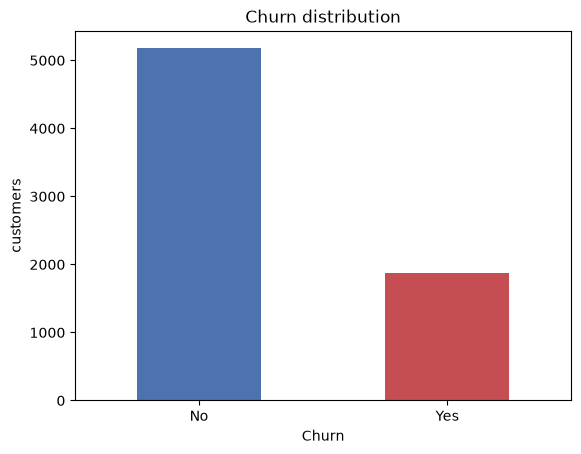

In [3]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts['Yes'] / len(df):.2%}")

churn_counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], title="Churn distribution")
plt.ylabel("customers")
plt.xticks(rotation=0)
plt.show()

## The `TotalCharges` gotcha

`TotalCharges` reads in as an `object` column, not numeric - `pandas.read_csv` doesn't error, it just infers a string dtype. The reason: 11 rows have a blank string instead of a number.

In [4]:
print(df["TotalCharges"].dtype)

blank_mask = df["TotalCharges"].str.strip() == ""
print(f"\n{blank_mask.sum()} rows with blank TotalCharges")
df.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

object

11 rows with blank TotalCharges


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Every single one has `tenure == 0` - brand-new customers who haven't been billed yet. That's why `churn_features.clean_total_charges()` treats a blank value as `$0` only when `tenure == 0`, and raises on any other blank value instead of silently zeroing it - a blank with nonzero tenure would be a real data problem, not this known case.

## Tenure vs. churn

Churn is heavily front-loaded: customers who leave tend to leave early.

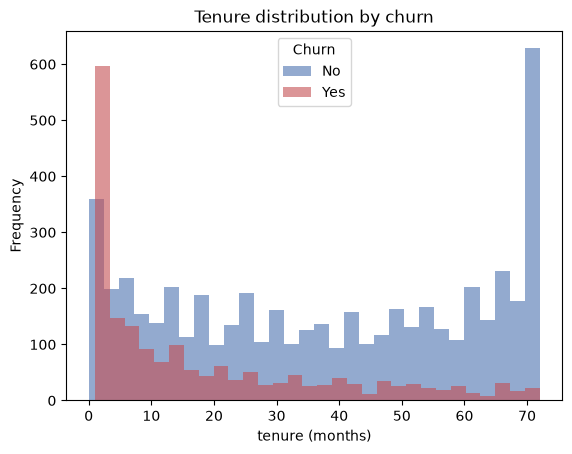

In [5]:
fig, ax = plt.subplots()
for label, color in [("No", "#4C72B0"), ("Yes", "#C44E52")]:
    df.loc[df["Churn"] == label, "tenure"].plot(
        kind="hist", bins=30, alpha=0.6, label=label, color=color, ax=ax
    )
ax.set_xlabel("tenure (months)")
ax.set_title("Tenure distribution by churn")
ax.legend(title="Churn")
plt.show()

## Contract type vs. churn

Month-to-month customers churn at a far higher rate than customers on a one- or two-year contract - one of the strongest signals in this dataset, and a sensible one (no cancellation penalty).

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


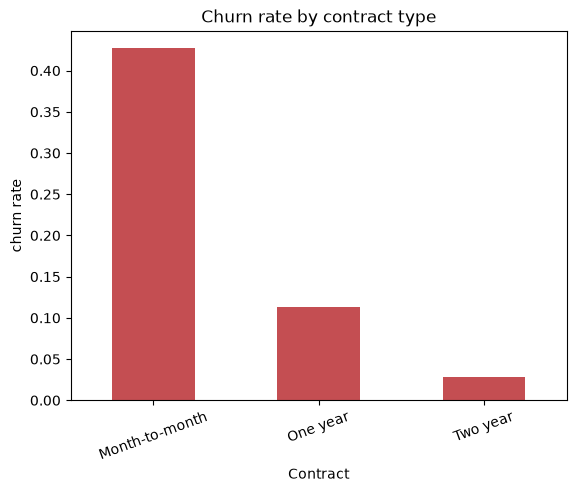

In [6]:
churn_rate_by_contract = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean())
churn_rate_by_contract = churn_rate_by_contract.sort_values(ascending=False)
print(churn_rate_by_contract)

churn_rate_by_contract.plot(kind="bar", color="#C44E52", title="Churn rate by contract type")
plt.ylabel("churn rate")
plt.xticks(rotation=20)
plt.show()

## Monthly charges vs. churn

Churned customers skew toward higher monthly charges - consistent with fiber/premium-service customers (see `InternetService` in `churn_features.CATEGORICAL_FEATURES`) being more price-sensitive or more likely to shop around.

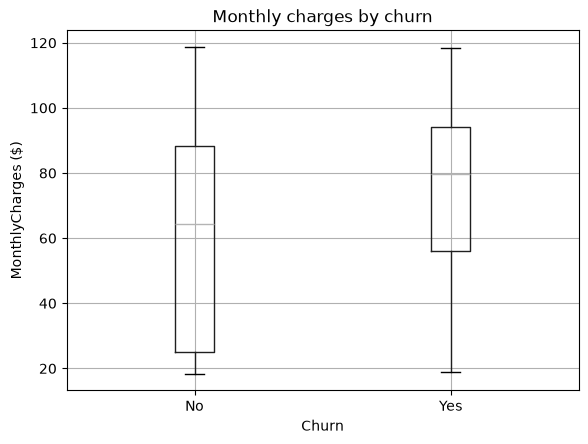

In [7]:
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly charges by churn")
plt.suptitle("")
plt.ylabel("MonthlyCharges ($)")
plt.show()

## Takeaways feeding into the model

- Class imbalance (~26.5% churn) is real but moderate - `scripts/train.py` computes `scale_pos_weight` from the actual training split rather than hardcoding it, trading some accuracy for better recall on churners.
- `Contract`, `tenure`, and `InternetService`/`MonthlyCharges` all show clear separation by eye - a reasonable prior that a gradient-boosted tree model should be able to pick up real signal from this feature set, not just noise.
- The `TotalCharges` dtype issue is handled once, centrally, in `churn_features.clean_total_charges()` - not re-derived here or anywhere else.